# UADAPy Demo

In [6]:
# Ensure imports work when running from examples/ directory
import sys
import os
if os.getcwd().endswith('examples'):
    sys.path.insert(0, os.path.abspath('..'))

## Distributions
UADAPy handles uncertainty through probability distributions. Therefore it's core is the **`Distribution`** class.

In [2]:
import numpy as np
from scipy import stats
from uadapy import Distribution
import matplotlib.pyplot as plt
from uadapy.plotting import plots_1d, plots_2d, plots_nd, stippling, plots_timeseries

In [3]:
# wrap any distribution object in UADAPy's unified Distribution interface
dist = Distribution(stats.multivariate_normal(np.zeros(2)))

# get some summary statistics
print(f"mean = {dist.mean()}. total variance = {np.trace(dist.cov())}.")

# draw samples from the distribution
samples = dist.sample(10000)

# determine probability densities at specific locations 
densities = dist.pdf(samples)
print(f"peak location = {samples[np.argmax(densities)]}")

mean = [0. 0.]. total variance = 2.0.
peak location = [-0.01321257  0.00031715]


### Data to Distribution
Distributions can be estimated from observations easily via KDE

In [8]:
from sklearn import datasets

iris = datasets.load_iris()
dists = []
for species in range(3):
    species_data = iris['data'][iris['target'] == species]
    # estimate distribution from data points (KDE)
    dists.append(Distribution(species_data))
    print(f"iris {iris['target_names'][species]} mean: {dists[species].mean()}")

iris setosa mean: [5.006 3.428 1.462 0.246]
iris versicolor mean: [5.936 2.77  4.26  1.326]
iris virginica mean: [6.588 2.974 5.552 2.026]


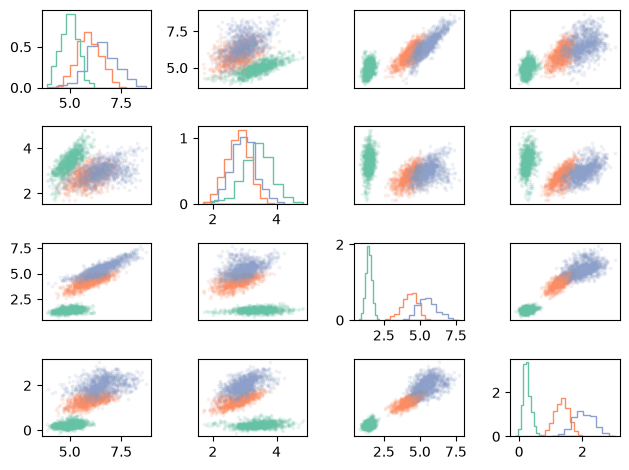

In [9]:
fig, ax = plots_nd.plot_samples(dists, n_samples=1000, show_plot=True, point_opacity=0.1, point_size=3)

## Visualizing distributions
UADAPy provides a convenient API to visualize distributions that usually requires lots of boilder plate code

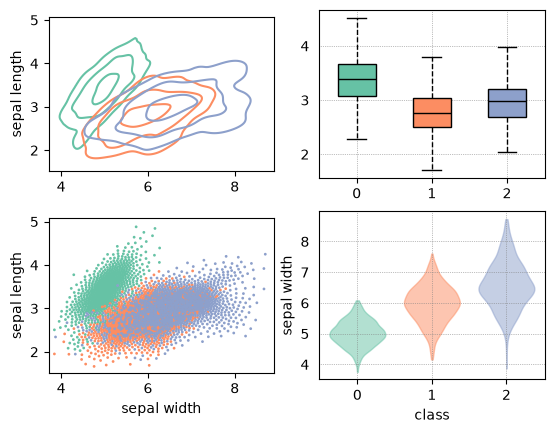

In [10]:
# lets show sepal width and length distributions
fig, axs = plt.subplots(2,2)
axs[0,0].sharex(axs[1,0])
axs[0,0].sharey(axs[1,0])
# labeling
axs[0,0].set_ylabel('sepal length')
axs[1,0].set_xlabel('sepal width')
axs[1,0].set_ylabel('sepal length')
axs[1,1].set_ylabel('sepal width')
axs[1,1].set_xlabel('class')
axs[0,0].set_aspect('equal')

# we can estimate the respective marginal distributions (dropping petal width and length) 
sepal_dists = [Distribution(d.sample(1000)[:,0:2]) for d in dists]
# same for the single attribute distributions
sw_dists = [Distribution(d.sample(1000)[:,0]) for d in dists]
sl_dists = [Distribution(d.sample(1000)[:,1]) for d in dists]


plots_2d.plot_contour(sepal_dists, fig=fig, axs=axs[0,0]) # .25, .75, .95 quantile contours (highest density regions)
stippling.plot_stipples(sepal_dists, resolution=128, seed=55, fig=fig, axs=axs[1,0])
plots_1d.plot_1d_distribution(sl_dists, 1000, plot_types=['boxplot'], fig=fig, axs=axs[0,1])
plots_1d.plot_1d_distribution(sw_dists, 1000, plot_types=['violinplot'], fig=fig, axs=axs[1,1])
fig;

## Uncertainty Aware Dimensionality Reduction
For high dimensional distributions, several dimensionality reduction methods that propagate uncertainty
can be employed.

*Note: UADAPy's dev team tries to integrate uncertainty-aware DR of our community whenever possible.*

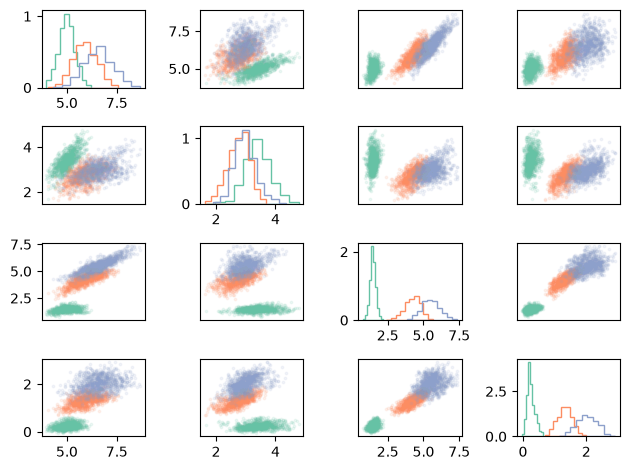

In [11]:
from uadapy.distributions import gmm_from_kde

# computing weighted gaussian mixture model uaPCA
# for this we transform KDE to GMM
gmms = [Distribution(gmm_from_kde(d.kde)) for d in dists]
fig, axs = plots_nd.plot_samples(gmms, n_samples=1000, show_plot=True, point_opacity=0.1, point_size=3)

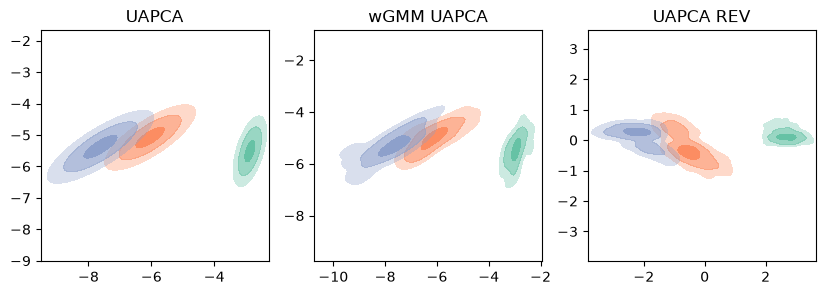

In [12]:
from uadapy.dr import uapca, uapca_revisited, wgmm_uapca

# computing uncertainty-aware PCA
uapca_projections = uapca(dists, n_dims=2)

# computing weighted GMM uncertainty-aware PCA
wgmm_projections = wgmm_uapca(gmms, n_dims=2)

# computing uncertainty-aware PCA REVISITED
# this technique yields samples from which we can estimate distributions
projected_samples = uapca_revisited(dists, n_dims=2, n_samples=1000)
uapca_r_projections = [Distribution(s) for s in projected_samples]

fig, axs = plt.subplots(1,3, figsize=(10,3))
axs[0].set_title('UAPCA')
plots_2d.plot_contour_bands(uapca_projections, fig=fig, axs=axs[0])
axs[1].set_title('wGMM UAPCA')
plots_2d.plot_contour_bands(wgmm_projections, fig=fig, axs=axs[1])
axs[2].set_title('UAPCA REV')
plots_2d.plot_contour_bands(uapca_r_projections, fig=fig, axs=axs[2])
for ax in axs:
    ax.set_aspect('equal', adjustable='datalim')

## Time Series
UADAPy supports modelling uncertain time series as distribution objects with additional time step information.

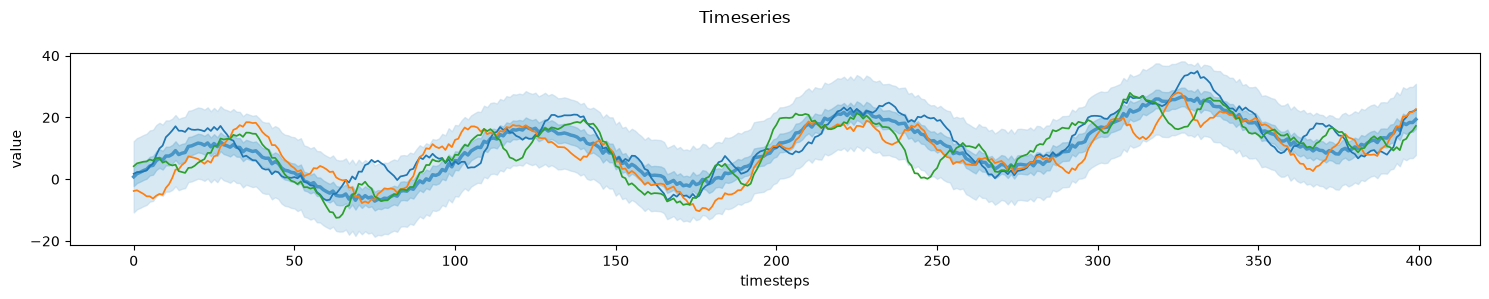

In [13]:
import uadapy.data as data
timeseries = data.generate_synthetic_timeseries(timesteps=400, trend=0.05) 
fig, axs = plots_timeseries.plot_timeseries(timeseries, n_samples=3, seed=55, show_plot=True)

(-1.0, 36000.0)

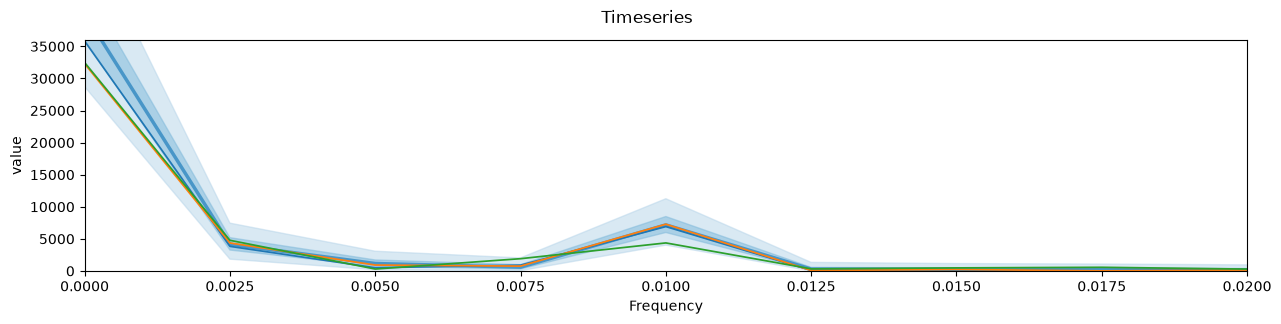

In [14]:
import uadapy.temporal.spectralAnalysis as spectralAnalysis

# Compute the Fourier spectrum of the uncertain time series
ua_spectrum = spectralAnalysis.ua_fourier_spectrum(timeseries)
fig, axs = plots_timeseries.plot_timeseries(ua_spectrum, n_samples=3, seed=42, percentiles=True, show_plot=False, x_label='Frequency')
axs.set_xlim(0.0, 0.02)
axs.set_ylim(-1, 36000)

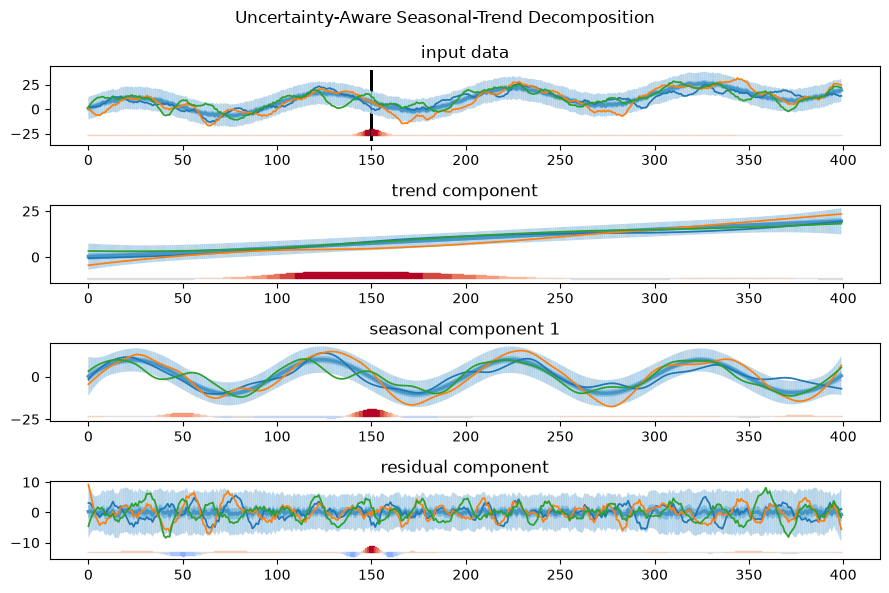

In [15]:
from uadapy.temporal.uastl import uastl

# Compute the UA STL decomposition of the uncertain time series
corr_timeseries = uastl(timeseries, [100])
fig, axs = plots_timeseries.plot_correlated_timeseries(corr_timeseries, n_samples=3, co_point=150, show_plot=True)

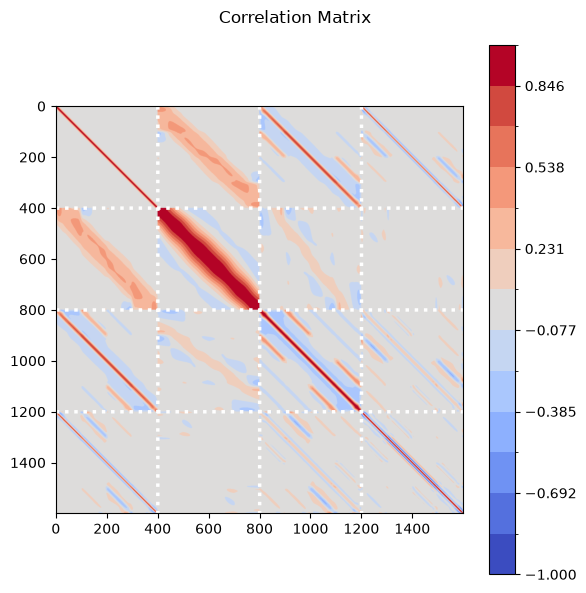

In [16]:
fig, axs = plots_timeseries.plot_correlation_matrix(corr_timeseries, show_plot=True)

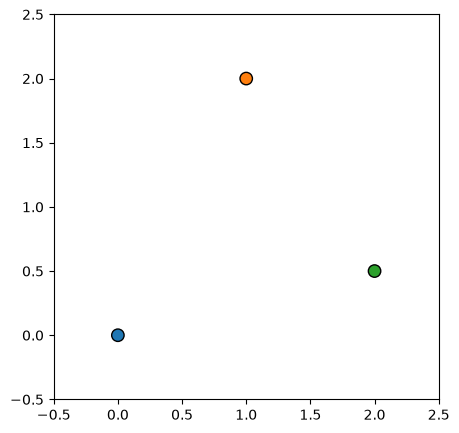

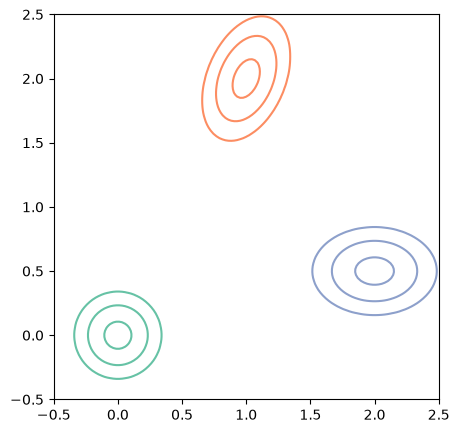

In [ ]:
# Just for example on slide, not part of the demo
# define three 2D points
import numpy as np
import matplotlib.pyplot as plt
from uadapy import Distribution
from uadapy.plotting import plots_2d
from scipy import stats

points = np.array([[0.0, 0.0],
                   [1.0, 2.0],
                   [2.0, 0.5]])

# quick scatter of the points
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(points[:,0], points[:,1], c=['C0','C1','C2'], s=80, edgecolor='k', zorder=3)
#ax.set_title('3 Points (means of distributions)')
ax.set_aspect('equal')
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-0.5, 2.5)

# create a small Gaussian around each point so the Distribution mean is the point
cov = np.eye(2) * 0.02  # small covariance so distributions are centered tightly on the points
covs = [cov, np.array([[0.02, 0.01], [0.01, 0.04]]), np.array([[0.04, 0], [0, 0.02]])]  # same covariance for all points
dists = [Distribution(stats.multivariate_normal(mean=pt, cov=cov)) for pt, cov in zip(points, covs)]

# plot the distributions (samples) and overlay the original points
fig2, ax2 = plt.subplots(figsize=(5,5))
fig2, ax2 = plots_2d.plot_contour(dists, show_plot=False, fig=fig2)
#ax2.scatter(points[:,0], points[:,1], c=['C0','C1','C2'], s=80, edgecolor='k', zorder=3)
#ax2.set_title('Distributions with means at the plotted points')
ax2.set_aspect('equal')
ax2.set_xlim(-0.5, 2.5)
ax2.set_ylim(-0.5, 2.5)

plt.show()